# 06. DECam Streak Photometry
Written by Kiyoaki Okudaira and Meredith Rawls<br>
*University of Washington / IAU CPS SatHub<br>
(kiyoaki@uw.edu or okudaira.kiyoaki.528@s.kyushu-u.ac.jp)<br>
<br>
This code is written for ASTR 499 undergraduate research with Dr. Meredith.<br>
A notebook to photometry satellite streak and query the SatChecker Field Of View (FOV) service.<br>
<br>
**History**<br>
coding 2026-02-21 : 1st coding

## Import and Initial Settings
### PATH setting

In [1]:
image_path = "/astro/store/shire/kiyoaki/ASTR499/input/fits_data/" # Directory where DECam images are saved | str
output_path = "/astro/store/shire/kiyoaki/ASTR499/output/"
group_num = 1
row_num   = 1

### Standard Libraries

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from os import path
import pickle
import json

from scipy.stats import sigmaclip
import requests

from IPython.display import clear_output

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from photutils.aperture import RectangularAperture, aperture_photometry

from tqdm.notebook import tqdm

### Satphotometry Library

In [3]:
import satphotometry as sp

### Load Streak Dataset
Dataset is grouped by EXPNUM because if the EXPNUM is the same, the request to satchecker is the same．

In [4]:
with open('{0}session/workspace_starlink_streak_table_cleaned.pkl'.format(output_path), 'rb') as f:
    streak_table = pickle.load(f)
streak_table = streak_table.group_by("expnum")
output = []

mag_arcsec_list = [None] * len(streak_table)

## Photometry

**Photometry**<br>
Zero point of All Legacy Survay processed images is 22.5. See detail [here](https://www.legacysurvey.org/dr1/description/)

In [ ]:
for row in streak_table[3:4]:
    basename = path.basename(row["archive_filename"])
    md5sum = row["md5sum"]
    expnum = row["expnum"]
    ccdnum = row["ccdnum"]
    streak_ID = row["streakID"]
    idx = np.where(streak_table["streakID"] == streak_ID)[0][0]

    save_path = image_path + path.splitext(path.splitext(basename)[0])[0] + "_CCD_{0}".format(ccdnum) + path.splitext(path.splitext(basename)[0])[1] + path.splitext(basename)[1]

    hdu = fits.open(save_path)
    main_header = hdu[0].header
    ccd_header = hdu[1].header
    ccd_data = hdu[1].data
    ccd_wcs = WCS(ccd_header)

    ccd_data = fits.getdata(save_path,1)
    rotated_img,r_matrix,r_pararell = sp.imgrotation.rotate_image(ccd_data, row["rt_angle"], row["initial_streak_coord"], True, 100, True)

    streak_x_min = row["streak_x_min"]
    streak_x_max = row["streak_x_max"]
    streak_y     = row["streak_y"]
    sigma_mean   = row["streak_sigma"]

    # rotation
    def _inv_rot(x, y, r_matrix, r_pararell, wcs):
        p = np.array([x, y], dtype=float)
        src_xy = r_matrix @ (p - r_pararell)
        src_radec = wcs.pixel_to_world(src_xy[0], src_xy[1])
        return src_xy,src_radec

    streak_sc_src_xy,streak_sc_radec = _inv_rot(streak_x_min, streak_y, r_matrix, r_pararell, ccd_wcs)
    streak_ec_src_xy,streak_ec_radec = _inv_rot(streak_x_max, streak_y, r_matrix, r_pararell, ccd_wcs)

    streak_s1_src_xy,streak_s1_radec = _inv_rot(streak_x_min, streak_y-3*sigma_mean, r_matrix, r_pararell, ccd_wcs)
    streak_s2_src_xy,streak_s2_radec = _inv_rot(streak_x_min, streak_y+3*sigma_mean, r_matrix, r_pararell, ccd_wcs)
    streak_e1_src_xy,streak_e1_radec = _inv_rot(streak_x_max, streak_y-3*sigma_mean, r_matrix, r_pararell, ccd_wcs)
    streak_e2_src_xy,streak_e2_radec = _inv_rot(streak_x_max, streak_y+3*sigma_mean, r_matrix, r_pararell, ccd_wcs)

    # image plot
    # quad for plot
    quad_x_src = [
        len(ccd_data[0]) - streak_s1_src_xy[0],
        len(ccd_data[0]) - streak_s2_src_xy[0],
        len(ccd_data[0]) - streak_e2_src_xy[0],
        len(ccd_data[0]) - streak_e1_src_xy[0],
        len(ccd_data[0]) - streak_s1_src_xy[0]
    ]

    quad_y_src = [
        streak_s1_src_xy[1],
        streak_s2_src_xy[1],
        streak_e2_src_xy[1],
        streak_e1_src_xy[1],
        streak_s1_src_xy[1]
    ]

    quad_x_rt = [
        0,
        0,
        streak_x_max - streak_x_min,
        streak_x_max - streak_x_min,
        0
    ]

    quad_y_rt = [
        streak_y-3*sigma_mean,
        streak_y+3*sigma_mean,
        streak_y+3*sigma_mean,
        streak_y-3*sigma_mean,
        streak_y-3*sigma_mean
    ]

    # Plot
    fig = plt.figure(figsize=(11, 24))

    gs = fig.add_gridspec(2, 1, height_ratios=[20,1], hspace=0)

    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1])


    # original image
    ax0.imshow(
        np.fliplr(ccd_data),
        cmap='gray',
        origin='lower',
        vmin=np.percentile(ccd_data, 5),
        vmax=np.percentile(ccd_data, 95)
    )

    ax0.plot(
        [len(ccd_data[0]) - streak_sc_src_xy[0],
        len(ccd_data[0]) - streak_ec_src_xy[0]],
        [streak_sc_src_xy[1],
        streak_ec_src_xy[1]],
        ":",
        lw=0.75,
        color="red",
        label="streak center (modified)"
    )

    ax0.fill(
        quad_x_src,
        quad_y_src,
        color="yellow",
        alpha=0.5,
        label="streak region (modified)"
    )

    ax0.set_xlim([0, len(ccd_data[0])])
    ax0.set_ylim([0, len(ccd_data)])
    ax0.set_aspect("equal")
    ax0.set_title(f"Exposure No.{expnum} / CCD No.{ccdnum} | Streak No.{streak_ID}")
    # ax0.legend()


    # rotated image
    ax1.imshow(
        rotated_img[:,streak_x_min:streak_x_max],
        cmap='gray',
        origin='lower',
        vmin=np.percentile(rotated_img[:,streak_x_min:streak_x_max], 5),
        vmax=np.percentile(rotated_img[:,streak_x_min:streak_x_max], 95)
    )

    ax1.axhline(
        streak_y,
        ls=":",
        color='red',
        lw=1,
        alpha=0.75,
        label="streak center (modified)"
    )

    ax1.fill(
        quad_x_rt,
        quad_y_rt,
        color="yellow",
        alpha=0.5,
        label="streak region (modified)"
    )

    ax1.set_xlim([0, streak_x_max-streak_x_min])

    ax1.set_aspect("equal")
    ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2)

    plt.show()

    # Gaussian fitting
    count_1d = np.ma.mean(rotated_img,axis=1)
    y_1d = np.arange(len(count_1d))
    popt,fitting,range_min,range_max = sp.LEOphotometry.gauss_fitting(count_1d,y_1d,False)

    plt.figure(figsize=(10, 10))
    plt.plot(y_1d,count_1d,label="1D Count")
    plt.plot(y_1d,fitting,label="Gaussian fitting",color='red',linestyle='--')
    plt.axvline(popt[1]-3*popt[2], color='C1', lw=1, alpha=0.75, label="Streak range")
    plt.axvline(popt[1]+3*popt[2], color='C1', lw=1, alpha=0.75)
    plt.legend()
    plt.show()

    # photometry
    width = streak_x_max-streak_x_min
    height = 6*sigma_mean

    # On-streak
    ap_in = RectangularAperture(((streak_x_min+streak_x_max)/2, streak_y), w=width, h=height, theta=0)

    # Off streak
    ap_out_1 = RectangularAperture(((streak_x_min+streak_x_max)/2, streak_y+height), w=width, h=height/2, theta=0)
    ap_out_2 = RectangularAperture(((streak_x_min+streak_x_max)/2, streak_y-height), w=width, h=height/2, theta=0)

    # Count and Area
    phot_in  = aperture_photometry(rotated_img, ap_in)
    phot_out_1 = aperture_photometry(rotated_img, ap_out_1)
    phot_out_2 = aperture_photometry(rotated_img, ap_out_2)

    sum_in  = phot_in["aperture_sum"][0]
    sum_out = phot_out_1["aperture_sum"][0] + phot_out_2["aperture_sum"][0]

    area_in  = ap_in.area
    area_out = ap_out_1.area + ap_out_2.area

    # Background
    bkg_mean  = sum_out/area_out

    # Flux
    arc_per_pix = 0.27
    flux_net = sum_in - bkg_mean * area_in
    flux_pix = flux_net/(width*height)
    flux_arcsec = flux_pix / (arc_per_pix**2)
    s_n = flux_pix/bkg_mean

    # Magnitude
    mag_arcsec = -2.5*np.log10(flux_arcsec) + 22.5

    if input("Is this streak region correct (Enter/n) : ") == "":
        mag_arcsec_list[idx] = mag_arcsec

        print("brightness of the streak : ")
        print(f"sum on-streak   = {sum_in:.2f} [HDU]")
        print(f"background mean = {bkg_mean:.2f} [HDU/(pix^2)]")
        print(f"flux on-streak  = {flux_net:.2f} [HDU]")
        print(f"flux on-streak  = {flux_pix:.2f} [HDU/(pix^2)]")
        print(f"flux on-streak  = {flux_arcsec:.2f} [HDU/(arcsec^2)]")
        print(f"mag on-streak   = {mag_arcsec:.2f} [MAG/(arcsec^2)]")
        print(f"S/N             = {s_n:.2f}")
    
    clear_output(wait=True)

In [ ]:
streak_table["mag_arcsec"] = mag_arcsec_list
with open('{0}session/workspace_starlink_streak_table_photometry.pkl'.format(output_path), 'wb') as f:
    pickle.dump(streak_table, f)

In [5]:
with open('{0}session/workspace_starlink_streak_table_photometry.pkl'.format(output_path), 'rb') as f:
    streak_table = pickle.load(f)
streak_table = streak_table.group_by("expnum")

In [6]:
# streak_table.remove_columns(["initial_streak_coord"])
streak_table.write(f"{output_path}starlink_streak_table_photometry.csv", overwrite=True)

In [7]:
streak_table = streak_table.group_by("norad_id")
streak_table

streakID,filename,rnum,ra_1,ra_2,ra_3,ra_4,dec_1,dec_2,dec_3,dec_4,expnum,ccdnum,band,width,height,area,archive_filename,filesize,dateobs_center,dateobs_min,dateobs_max,airmass,seeing,magzero,img_availability,md5sum,file_availablity,gauss_availability,initial_rt_angle,rt_angle,second_gauss_availability,amplitude_mean,mu_mean,mu_std,sigma_mean,s_n_mean,mask_ratio,sc_ra,ec_ra,s1_ra,s2_ra,e1_ra,e2_ra,sc_dec,ec_dec,s1_dec,s2_dec,e1_dec,e2_dec,streak_y,streak_x_min,streak_x_max,streak_sigma,name,norad_id,angle_error,cross_error,along_error,mag_arcsec,generation,fwhm,omega_arcsec_s,mag_corr,mag_stat,mag_zen,mag_raw
int64,str37,int64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,str1,float64,float64,float64,str79,int64,str27,int64,int64,float64,float64,object,str4,str32,object,object,object,object,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,object,object,object,object,object,object,str4,object,float64,object,object,object,object
19961,D01163588_g_c18_r6079p01_hstreak.fits,1,14.575879,14.582895,14.435058,14.428036,3.487528,3.479884,3.34435,3.352,1163588,18,g,37.320948,721.327244,26920.616706,/net/archive/pipe/20230108/ct4m/2021A-0275/c4d_230109_011850_ooi_g_yse.fits.fz,317583360,2023-01-09T01:19:15.762327Z,--,--,1.66,1.07,29.117,True,78d2ee86f14dd9bee642cc2cc6fb8e90,True,True,-47.37636707534909,-46.37844069129445,True,3.814900792509664,3.814900792509664,3.814900792509664,3.814900792509664,3.814900792509664,3.814900792509664,14.566989852586449,14.442764413389012,14.56641318726851,14.567566513630428,14.442187373680321,14.443341448446686,3.4752003128592266,3.3572561651278106,3.475807121800404,3.4745935026903068,3.357863358474739,3.3566489717613153,93.07136723685522,0,2349,3.814900792509664,STARLINK-1166,45060,0.17196082947100422,181.5216694315161,24.012708170210484,12.630283645793568,v1,2.42570466891727,1032.9380470277692,14.999858634953522,5.926795055266311,4.826254615066036,19.24728364579357
19962,D01163588_g_c23_r6079p01_hstreak.fits,1,14.399115,14.40572,14.244818,14.238206,3.323035,3.316199,3.160806,3.167645,1163588,23,g,34.192541,804.620237,27512.010706,/net/archive/pipe/20230108/ct4m/2021A-0275/c4d_230109_011850_ooi_g_yse.fits.fz,317583360,2023-01-09T01:19:15.762327Z,--,--,1.66,1.07,29.117,True,78d2ee86f14dd9bee642cc2cc6fb8e90,True,True,-45.87718554511627,-46.38205565818549,True,3.691658822560859,3.691658822560859,3.691658822560859,3.691658822560859,3.691658822560859,3.691658822560859,14.394556960962856,14.251484881387514,14.393998832844876,14.39511508472224,14.250926230414361,14.252043528345252,3.311505802111138,3.1757592386285727,3.3120939162724374,3.310917688545254,3.176347593715043,3.1751708825937364,94.42594134231044,0,2699,3.691658822560859,STARLINK-1166,45060,0.15479329684612964,181.57937550364906,874.1456370116415,12.59541163247344,v1,2.3473412623253225,1032.9380470277692,14.964986621633393,5.92757726973886,4.827036829538585,19.21241163247344
19963,D01163588_g_c29_r6079p01_hstreak.fits,1,14.226491,14.233084,14.071052,14.064454,3.158732,3.151869,2.996352,3.003215,1163588,29,g,34.235361,807.922641,27659.523379,/net/archive/pipe/20230108/ct4m/2021A-0275/c4d_230109_011850_ooi_g_yse.fits.fz,317583360,2023-01-09T01:19:15.762327Z,--,--,1.66,1.07,29.117,True,78d2ee86f14dd9bee642cc2cc6fb8e90,True,True,-46.07390284408828,-46.414242629680395,True,3.6299210473667074,3.6299210473667074,3.6299210473667074,3.6299210473667074,3.6299210473667074,3.6299210473667074,14.216240564096154,14.078166719036751,14.215691249800999,14.216789875026992,14.077616993293546,14.07871644115834,3.1422629356359537,3.0113066249770215,3.1428414497144956,3.141684419580406,3.0118851501350017,3.010728103436619,93.82960976463667,100,2699,3.6299210473667074,STARLINK-1166,45060,0.4274592559925878,188.7273792048616,0.0,12.501552687021643,v1,2.308085297968121,1032.9380470277692,14.871127676181597,5.852029270204

In [8]:
arc_per_pix = 0.27

mag_raw_list        = [None] * len(streak_table)
fwhm_list           = [None] * len(streak_table)
omega_arcsec_s_list = [None] * len(streak_table)
mag_corr_list       = [None] * len(streak_table)
mag_stat_list       = [None] * len(streak_table)
mag_zen_list        = [None] * len(streak_table)

for row in streak_table:
    if row["mag_arcsec"] == None or row["magzero"] == None:
        continue
    basename = path.basename(row["archive_filename"])
    md5sum = row["md5sum"]
    expnum = row["expnum"]
    ccdnum = row["ccdnum"]
    streak_ID = row["streakID"]
    idx = np.where(streak_table["streakID"] == streak_ID)[0][0]

    save_path = image_path + path.splitext(path.splitext(basename)[0])[0] + "_CCD_{0}".format(ccdnum) + path.splitext(path.splitext(basename)[0])[1] + path.splitext(basename)[1]

    hdu = fits.open(save_path)
    main_header = hdu[0].header
    exptime = main_header["EXPTIME"]

    mag_raw = row["mag_arcsec"] + (row["magzero"] - 22.5)

    mag_corr = mag_raw - 2.5 * np.log10(exptime)
    fwhm = (2.355 * row["streak_sigma"]) * arc_per_pix

    data = json.load(open(output_path + "satchecker/" + path.splitext(path.splitext(basename)[0])[0] + "_satchecker.json", 'r'))
    positions = data["data"]["satellites"][f"{row["name"]} ({row["norad_id"]})"]["positions"]

    ra1  = positions[0]["ra"]
    dec1 = positions[0]["dec"]
    jd1  = positions[0]["julian_date"]
    ra2  = positions[-1]["ra"]
    dec2 = positions[-1]["dec"]
    jd2  = positions[-1]["julian_date"]

    c1 = SkyCoord(ra=ra1*u.deg, dec=dec1*u.deg, frame="icrs")
    c2 = SkyCoord(ra=ra2*u.deg, dec=dec2*u.deg, frame="icrs")

    delta_theta_deg = c1.separation(c2).deg

    delta_t_sec = (jd2 - jd1) * 86400.0

    omega_deg_s = delta_theta_deg / delta_t_sec
    omega_arcsec_s = omega_deg_s * 3600.0

    mag_stat = mag_corr - 2.5 * np.log10(omega_arcsec_s * fwhm)
    mag_zen  = mag_stat - 5 * np.log10(row["airmass"])

    mag_raw_list[idx] = mag_raw
    fwhm_list[idx] = fwhm
    omega_arcsec_s_list[idx] = omega_arcsec_s
    mag_corr_list[idx] = mag_corr
    mag_stat_list[idx] = mag_stat
    mag_zen_list[idx] = mag_zen

streak_table["mag_raw"] = mag_raw_list
streak_table["fwhm"] = fwhm_list
streak_table["omega_arcsec_s"] = omega_arcsec_s
streak_table["mag_corr"] = mag_corr_list
streak_table["mag_stat"] = mag_stat_list
streak_table["mag_zen"] = mag_zen_list

In [9]:
streak_table

streakID,filename,rnum,ra_1,ra_2,ra_3,ra_4,dec_1,dec_2,dec_3,dec_4,expnum,ccdnum,band,width,height,area,archive_filename,filesize,dateobs_center,dateobs_min,dateobs_max,airmass,seeing,magzero,img_availability,md5sum,file_availablity,gauss_availability,initial_rt_angle,rt_angle,second_gauss_availability,amplitude_mean,mu_mean,mu_std,sigma_mean,s_n_mean,mask_ratio,sc_ra,ec_ra,s1_ra,s2_ra,e1_ra,e2_ra,sc_dec,ec_dec,s1_dec,s2_dec,e1_dec,e2_dec,streak_y,streak_x_min,streak_x_max,streak_sigma,name,norad_id,angle_error,cross_error,along_error,mag_arcsec,generation,fwhm,omega_arcsec_s,mag_corr,mag_stat,mag_zen,mag_raw
int64,str37,int64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,str1,float64,float64,float64,str79,int64,str27,int64,int64,float64,float64,object,str4,str32,object,object,object,object,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,object,object,object,object,object,object,str4,object,float64,object,object,object,object
19961,D01163588_g_c18_r6079p01_hstreak.fits,1,14.575879,14.582895,14.435058,14.428036,3.487528,3.479884,3.34435,3.352,1163588,18,g,37.320948,721.327244,26920.616706,/net/archive/pipe/20230108/ct4m/2021A-0275/c4d_230109_011850_ooi_g_yse.fits.fz,317583360,2023-01-09T01:19:15.762327Z,--,--,1.66,1.07,29.117,True,78d2ee86f14dd9bee642cc2cc6fb8e90,True,True,-47.37636707534909,-46.37844069129445,True,3.814900792509664,3.814900792509664,3.814900792509664,3.814900792509664,3.814900792509664,3.814900792509664,14.566989852586449,14.442764413389012,14.56641318726851,14.567566513630428,14.442187373680321,14.443341448446686,3.4752003128592266,3.3572561651278106,3.475807121800404,3.4745935026903068,3.357863358474739,3.3566489717613153,93.07136723685522,0,2349,3.814900792509664,STARLINK-1166,45060,0.17196082947100422,181.5216694315161,24.012708170210484,12.630283645793568,v1,2.42570466891727,1032.9380470277692,14.999858634953522,5.926795055266311,4.826254615066036,19.24728364579357
19962,D01163588_g_c23_r6079p01_hstreak.fits,1,14.399115,14.40572,14.244818,14.238206,3.323035,3.316199,3.160806,3.167645,1163588,23,g,34.192541,804.620237,27512.010706,/net/archive/pipe/20230108/ct4m/2021A-0275/c4d_230109_011850_ooi_g_yse.fits.fz,317583360,2023-01-09T01:19:15.762327Z,--,--,1.66,1.07,29.117,True,78d2ee86f14dd9bee642cc2cc6fb8e90,True,True,-45.87718554511627,-46.38205565818549,True,3.691658822560859,3.691658822560859,3.691658822560859,3.691658822560859,3.691658822560859,3.691658822560859,14.394556960962856,14.251484881387514,14.393998832844876,14.39511508472224,14.250926230414361,14.252043528345252,3.311505802111138,3.1757592386285727,3.3120939162724374,3.310917688545254,3.176347593715043,3.1751708825937364,94.42594134231044,0,2699,3.691658822560859,STARLINK-1166,45060,0.15479329684612964,181.57937550364906,874.1456370116415,12.59541163247344,v1,2.3473412623253225,1032.9380470277692,14.964986621633393,5.92757726973886,4.827036829538585,19.21241163247344
19963,D01163588_g_c29_r6079p01_hstreak.fits,1,14.226491,14.233084,14.071052,14.064454,3.158732,3.151869,2.996352,3.003215,1163588,29,g,34.235361,807.922641,27659.523379,/net/archive/pipe/20230108/ct4m/2021A-0275/c4d_230109_011850_ooi_g_yse.fits.fz,317583360,2023-01-09T01:19:15.762327Z,--,--,1.66,1.07,29.117,True,78d2ee86f14dd9bee642cc2cc6fb8e90,True,True,-46.07390284408828,-46.414242629680395,True,3.6299210473667074,3.6299210473667074,3.6299210473667074,3.6299210473667074,3.6299210473667074,3.6299210473667074,14.216240564096154,14.078166719036751,14.215691249800999,14.216789875026992,14.077616993293546,14.07871644115834,3.1422629356359537,3.0113066249770215,3.1428414497144956,3.141684419580406,3.0118851501350017,3.010728103436619,93.82960976463667,100,2699,3.6299210473667074,STARLINK-1166,45060,0.4274592559925878,188.7273792048616,0.0,12.501552687021643,v1,2.308085297968121,1032.9380470277692,14.871127676181597,5.852029270204

In [10]:
len(streak_table.groups)

38

In [11]:
starlink_generation = [None] * len(streak_table)

In [12]:
for group in streak_table.groups:
    url = 'https://satchecker.cps.iau.org/tools/get-satellite-data/'
    params = {'id': group[0]["norad_id"],
              'id_type': 'catalog'
            }

    r = requests.get(url, params=params)

    if r.status_code == 200:
        generation = r.json()["data"][0]["generation"]

        for row in group:
            streak_ID = row["streakID"]
            idx = np.where(streak_table["streakID"] == streak_ID)[0][0]
            starlink_generation[idx] = generation

In [13]:
# streak_table["generation"] = starlink_generation
with open('{0}session/workspace_starlink_streak_table_photometry.pkl'.format(output_path), 'wb') as f:
    pickle.dump(streak_table, f)

In [14]:
with open('{0}session/workspace_starlink_streak_table_photometry.pkl'.format(output_path), 'rb') as f:
    streak_table = pickle.load(f)

In [15]:
altitude_list = []
azimuth_list  = []

for row in streak_table:
    basename = path.basename(row["archive_filename"])
    data = json.load(open(output_path + "satchecker/" + path.splitext(path.splitext(basename)[0])[0] + "_satchecker.json", 'r'))
    positions = data["data"]["satellites"][f"{row["name"]} ({row["norad_id"]})"]["positions"]
    altitudes = [d["altitude"] for d in positions]
    azimuths  = [d["azimuth"] for d in positions]

    mean_altitude = np.mean(altitudes)
    mean_azimuth  = np.mean(azimuths)

    altitude_list.append(mean_altitude)
    azimuth_list.append(mean_azimuth)

streak_table["al"] = altitude_list
streak_table["az"] = azimuth_list

In [16]:
streak_table_masked = streak_table[(streak_table["mag_arcsec"] != None) & (streak_table["magzero"] != None)]
streak_table_masked = streak_table_masked.group_by("generation")

In [17]:
len(streak_table_masked)

163

/astro/store/shire/kiyoaki/miniconda/envs/499/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:396: RuntimeWarning: invalid value encountered in greater_equal
  keep = (a >= first_edge)
/astro/store/shire/kiyoaki/miniconda/envs/499/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:397: RuntimeWarning: invalid value encountered in less_equal
  keep &= (a <= last_edge)
/astro/store/shire/kiyoaki/miniconda/envs/499/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:837: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/astro/store/shire/kiyoaki/miniconda/envs/499/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:838: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


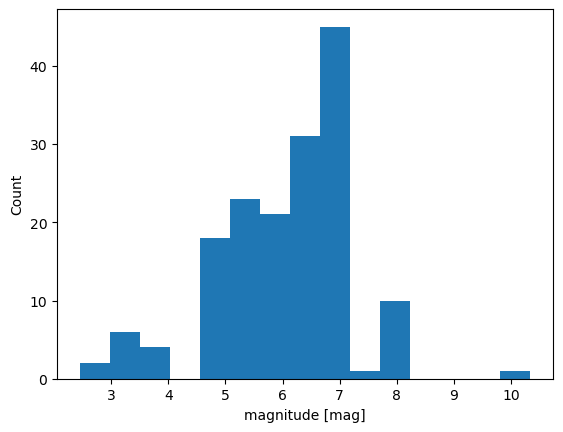

In [18]:
_ = plt.hist(streak_table_masked['mag_zen'], bins="auto")
plt.xlabel("magnitude [mag]")
plt.ylabel("Count")
plt.show()

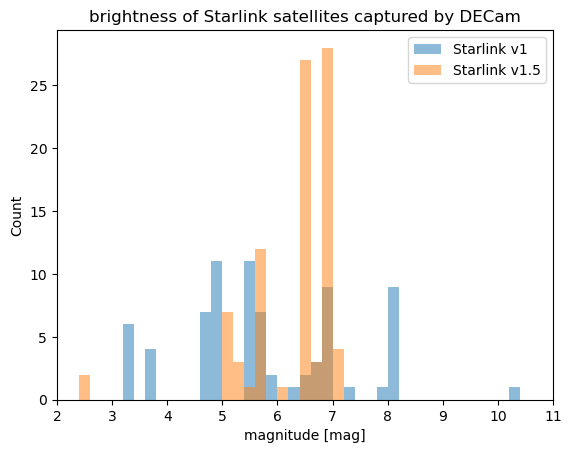

In [19]:
bin_width = 0.2
bins = np.arange(2, 12 + bin_width, bin_width)

plt.xlim([2,11])

for group in streak_table_masked.groups:
    plt.hist(group['mag_zen'], bins=bins, alpha=0.5, label="Starlink "+group[0]["generation"])

plt.xlabel("magnitude [mag]")
plt.ylabel("Count")
plt.legend()
plt.title("brightness of Starlink satellites captured by DECam")
plt.show()

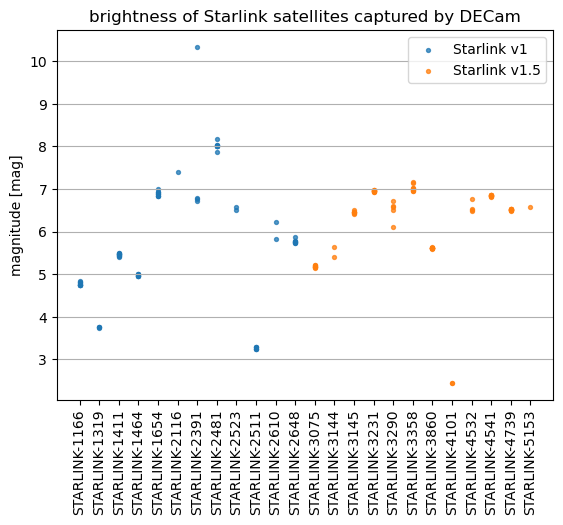

In [20]:
# streak_table_masked = streak_table_masked.group_by("norad_id")
for group in streak_table_masked.groups:
    plt.scatter(group["name"], group["mag_zen"], s=8, alpha=0.75, label="Starlink "+group[0]["generation"])
plt.xticks(rotation=90)
plt.legend()
plt.grid(axis='y')
plt.ylabel("magnitude [mag]")
plt.title("brightness of Starlink satellites captured by DECam")
plt.show()

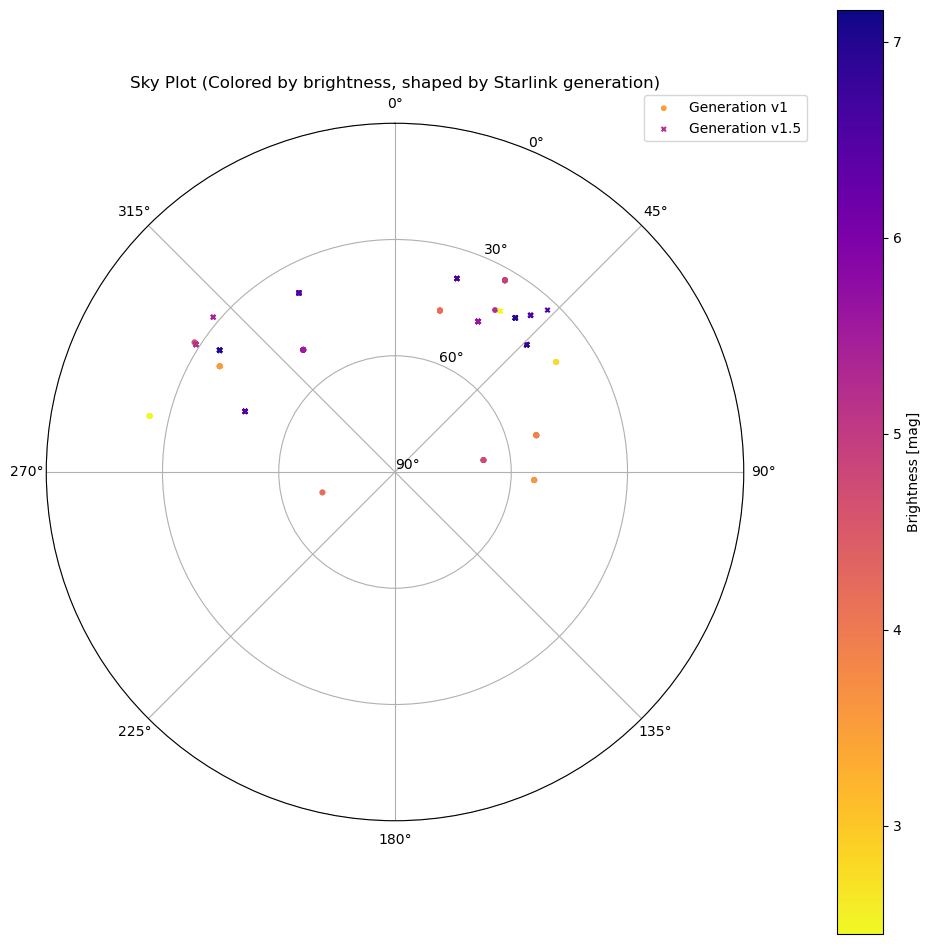

In [21]:
az = np.deg2rad(streak_table_masked["az"])
alt = streak_table_masked["al"]
mag = streak_table_masked["mag_zen"]
gen = streak_table_masked["generation"]

r = 90 - alt

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, polar=True)

# generationの種類を取得
generations = np.unique(gen)

markers = ["o", "x"]  # 2種類（必要なら増やせる）

for i, g in enumerate(generations):
    mask = (gen == g)

    sc = ax.scatter(
        az[mask],
        r[mask],
        c=mag[mask],
        cmap="plasma_r",
        s=10,
        marker=markers[i % len(markers)],
        label=f"Generation {g}"
    )

# 方位設定
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

ax.set_ylim(0, 90)
ax.set_rgrids([0, 30, 60, 90], labels=["90°", "60°", "30°", "0°"])

# カラーバー（最後のscatterを使う）
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Brightness [mag]")

# 凡例
ax.legend(loc="upper right", bbox_to_anchor=(1.1, 1.05))

ax.set_title("Sky Plot (Colored by brightness, shaped by Starlink generation)")

plt.show()

In [ ]:
streak_table_masked['mag_arcsec'].argmin()

In [ ]:
streak_table_masked[streak_table_masked['mag_arcsec'] < 10]

In [ ]:
url = 'https://satchecker.cps.iau.org/tools/get-satellite-data/'
params = {'id': 53142,
            'id_type': 'catalog'
        }

r = requests.get(url, params=params)
r.json()

In [24]:
len(streak_table)

230

In [27]:
streak_table = streak_table.group_by("expnum")

In [28]:
len(streak_table.groups)

36

In [29]:
i = 0
for group in streak_table.groups:
    if group[0]["magzero"] == None:
        i = i + 1
print(i)

9
